## Code V3 

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [42]:
# Read the CSV and parse dates
merged_df = pd.read_csv('merged_data.csv', parse_dates=['Date'])
merged_df.set_index('Date', inplace=True)

# Filter by date range
start_date = '2017-01-01'
end_date = '2018-12-31'
merged_df = merged_df[(merged_df.index >= start_date) & (merged_df.index <= end_date)]

/var/folders/07/l8m36_9s2lz170jptjv7r6jc0000gn/T/ipykernel_72215/2263201366.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged_df = pd.read_csv('merged_data.csv', parse_dates=['Date'])


In [43]:
# Convert all to numeric
merged_df = merged_df.apply(pd.to_numeric, errors='coerce')

# # Fill NaN values with column mean
# def fill_by_mean(df):
#     df = df.replace([np.inf, -np.inf], np.nan)
#     return df.fillna(df.mean())
# prices = fill_by_mean(merged_df)

In [44]:

prices = merged_df.copy()

# Check
prices.head(5)

,CG,BAC,CME,MS-PF,JPM,BLK
Date,,,,,,
2017-01-02,13.104505,NaN,100.901749,20.161367,73.657845,320.642426
2017-01-03,12.426118,21.159664,105.992722,21.069468,81.158020,341.969910
2017-01-04,NaN,21.554119,NaN,NaN,NaN,NaN
2017-01-05,13.657187,21.300541,97.869164,21.554190,76.358383,331.320923
2017-01-06,13.850858,21.300541,98.859245,21.814419,72.850075,359.799683


In [45]:
prices = prices.dropna()

In [46]:
prices.head(5)

,CG,BAC,CME,MS-PF,JPM,BLK
Date,,,,,,
2017-01-03,12.426118,21.159664,105.992722,21.069468,81.158020,341.969910
2017-01-05,13.657187,21.300541,97.869164,21.554190,76.358383,331.320923
2017-01-06,13.850858,21.300541,98.859245,21.814419,72.850075,359.799683
2017-01-09,16.586140,21.178444,106.532440,22.036579,80.870407,369.329346
2017-01-11,17.454935,21.666819,115.471291,21.614103,89.521812,410.931274


In [47]:
stocks = prices.columns
returns = prices.pct_change().dropna()
log_prices = np.log(prices)
log_returns = log_prices.diff().dropna()

form_start = '2017-01-01'
form_end = '2017-12-31'

trade_start = '2018-01-01'
trade_end = '2018-12-31'

prices_form = prices.loc[form_start:form_end].dropna()
prices_trade = prices.loc[trade_start:trade_end].dropna()

log_prices_form = log_prices.loc[form_start:form_end].dropna()
log_prices_trade = log_prices.loc[trade_start:trade_end].dropna()

log_returns_form = log_returns.loc[form_start:form_end].dropna()
log_returns_trade = log_returns.loc[trade_start:trade_end].dropna()

returns_form = returns.loc[form_start:form_end].dropna()
returns_trade = returns.loc[trade_start:trade_end].dropna()

In [48]:
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
import pandas as pd

### 直接从这边开始看

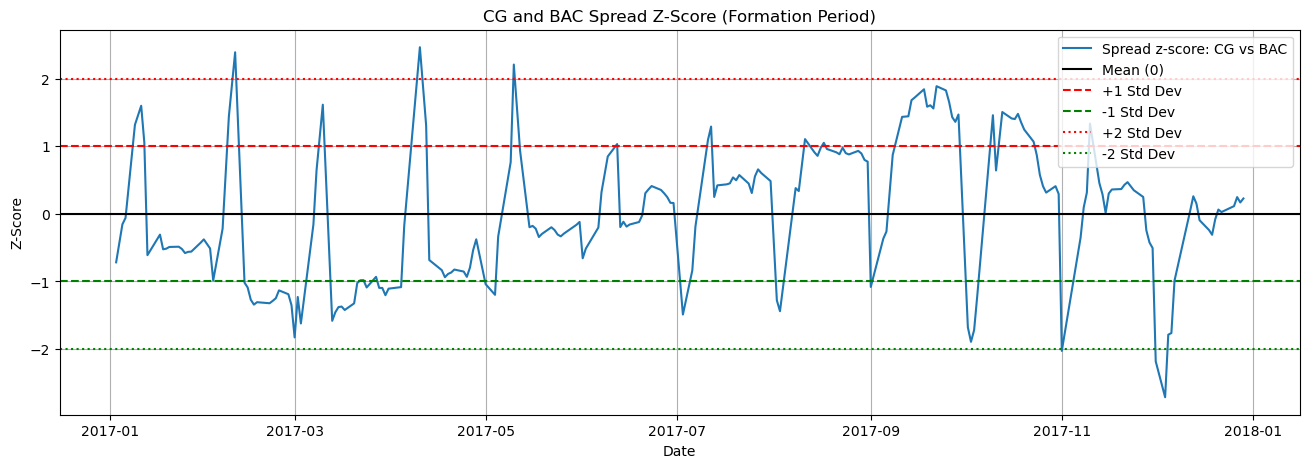

ADF p-value for spread (CG, BAC): 0.5146


In [49]:
# In-sample test: analyze the spread behavior for each cointegrated pair
# for i in range(len(cointegrated_pairs)):
s1 = 'CG' #cointegrated_pairs.loc[i, 's1']
s2 = 'BAC' #cointegrated_pairs.loc[i, 's2']

# Use formation period data
# y = log_prices_form[s1]
# x = log_prices_form[s2]

y = prices_form[s1]
x = prices_form[s2]

# Regress y on x
model = sm.OLS(y, sm.add_constant(x)).fit()
hedge_ratio = model.params[1]

# Create spread
spread = y - hedge_ratio * x
zscore = (spread - spread.mean()) / spread.std()

# Plot spread and z-score
plt.figure(figsize=(16, 5))
line_z = plt.plot(zscore, label=f'Spread z-score: {s1} vs {s2}')
line_0 = plt.axhline(0, color='black', label='Mean (0)')
line_1 = plt.axhline(1, color='red', linestyle='--', label='+1 Std Dev')
line_m1 = plt.axhline(-1, color='green', linestyle='--', label='-1 Std Dev')
line_2 = plt.axhline(2, color='red', linestyle=':', label='+2 Std Dev')
line_m2 = plt.axhline(-2, color='green', linestyle=':', label='-2 Std Dev')

plt.title(f'{s1} and {s2} Spread Z-Score (Formation Period)')
plt.xlabel("Date")
plt.ylabel("Z-Score")
plt.grid(True)
plt.legend(loc='best')
plt.show()

# Conduct ADF test on spread again
adf_test = adfuller(spread)
print(f"ADF p-value for spread ({s1}, {s2}): {adf_test[1]:.4f}")

# if adf_test[1] < 0.05:
#     print(f"Spread is stationary for {s1} and {s2}.")
# else:
#     # remove from cointegrated pairs
#     cointegrated_pairs = cointegrated_pairs.drop(i)
#     print(f"Spread is not stationary for {s1} and {s2}. \nWe kick this pair out.")

In [50]:
# Spread and z-score in trading period
# spread_trade = log_prices_trade[s1] - hedge_ratio * log_prices_trade[s2]
spread_trade = prices_trade[s1] - hedge_ratio * prices_trade[s2]
spread_mean = spread_trade.mean()
spread_std = spread_trade.std()
zscore_trade = (spread_trade - spread_mean) / spread_std

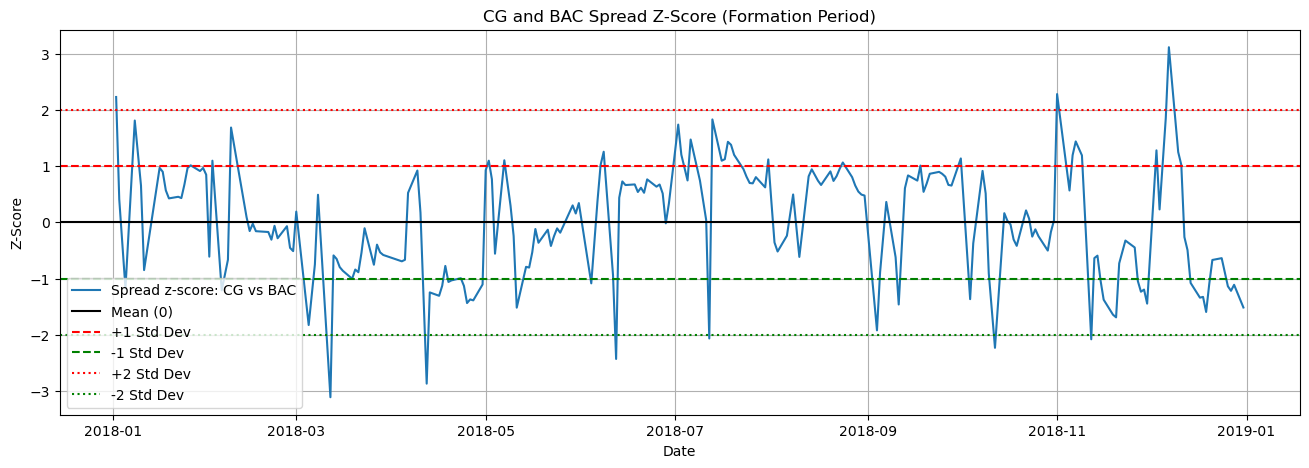

In [51]:
# Plot spread and z-score
plt.figure(figsize=(16, 5))
line_z = plt.plot(zscore_trade, label=f'Spread z-score: {s1} vs {s2}')
line_0 = plt.axhline(0, color='black', label='Mean (0)')
line_1 = plt.axhline(1, color='red', linestyle='--', label='+1 Std Dev')
line_m1 = plt.axhline(-1, color='green', linestyle='--', label='-1 Std Dev')
line_2 = plt.axhline(2, color='red', linestyle=':', label='+2 Std Dev')
line_m2 = plt.axhline(-2, color='green', linestyle=':', label='-2 Std Dev')

plt.title(f'{s1} and {s2} Spread Z-Score (Formation Period)')
plt.xlabel("Date")
plt.ylabel("Z-Score")
plt.grid(True)
plt.legend(loc='best')
plt.show()

In [52]:
# Trading signals
entry_signal = np.where(zscore_trade > 1, -1, np.where(zscore_trade < -1, 1, np.nan))
exit_signal = np.where(abs(zscore_trade) <=1, 0, np.nan)

entry_signal[exit_signal==0]=0

# Build positions
positions = pd.Series(entry_signal,index=zscore_trade.index).copy()
s1_trade = positions.copy()
s2_trade = positions.copy()

In [53]:
for i in range(len(positions)-1):
    if i == 0:
        if entry_signal[i] == -1:
            s1_trade[positions.index[i]] = 2
            s2_trade[positions.index[i]] = 1
        elif entry_signal[i] == 1:
            s1_trade[positions.index[i]] = 1
            s2_trade[positions.index[i]] = 2
        else:
            s1_trade[positions.index[i]] = np.nan
            s2_trade[positions.index[i]] = np.nan
    else:
        if entry_signal[i] == -1:
            s1_trade[positions.index[i]] = 2
            s2_trade[positions.index[i]] = 1
        elif entry_signal[i] == 1:
            s1_trade[positions.index[i]] = 1
            s2_trade[positions.index[i]] = 2
        elif entry_signal[i] == 0 :
            if entry_signal[i-1]==-1:
                positions[positions.index[i]]=1
                s1_trade[positions.index[i]] = 1
                s2_trade[positions.index[i]] = 2
                # print(i,entry_signal[i])
            elif entry_signal[i-1]== 1:
                positions[positions.index[i]]=-1
                # entry_signal[i+1] = np.nan if entry_signal[i+1]==0 else entry_signal[i+1]
                s1_trade[positions.index[i]] = 2
                s2_trade[positions.index[i]] = 1
            else:
                if entry_signal[np.where(~np.isnan(entry_signal[:i]))[0][-1]] == -1:
                    positions[positions.index[i]]=1
                    s1_trade[positions.index[i]] = 1
                    s2_trade[positions.index[i]] = 2
                elif entry_signal[np.where(~np.isnan(entry_signal[:i]))[0][-1]] == 1:
                    positions[positions.index[i]]=-1
                    s1_trade[positions.index[i]] = 2
                    s2_trade[positions.index[i]] = 1
                else:
                    positions[positions.index[i]]= np.nan
                    s1_trade[positions.index[i]] = np.nan
                    s2_trade[positions.index[i]] = np.nan
        else:
            s1_trade[positions.index[i]] = np.nan
            s2_trade[positions.index[i]] = np.nan

In [54]:
df_s1 = pd.DataFrame(returns_trade[s1].reset_index()).rename(columns = {s1:'changepct'})
df_s1['code'] = s1
df_s2 = pd.DataFrame(hedge_ratio*returns_trade[s2]).reset_index().rename(columns = {s2:'changepct'})
df_s2['code'] = s2
df_s1['trade'] = df_s1['Date'].map(s1_trade)
df_s2['trade'] = df_s2['Date'].map(s2_trade)
df_return = pd.concat([df_s1,df_s2], axis=0)

In [55]:
np.cumprod(1+(df_return.dropna()).groupby(['Date'])['changepct'].sum())

Date
2018-01-02    1.136575
2018-01-03    1.007471
2018-01-05    0.927081
2018-01-08    1.121670
2018-01-10    1.065694
                ...   
2018-12-21    0.998216
2018-12-26    1.048048
2018-12-27    1.058801
2018-12-28    1.070574
2018-12-31    1.049377
Name: changepct, Length: 106, dtype: float64

In [56]:
# Trading signals
threshold = 1
entry_signal = np.where(zscore_trade > threshold, -1, np.where(zscore_trade < -threshold, 1, 0))
# exit_signal = np.where(abs(zscore_trade) < 0.5, 0, np.nan)
# exit_signal = np.where(abs(zscore_trade) <= threshold, 0, np.nan)

In [57]:
# Build positions
positions = pd.Series(entry_signal,index=zscore_trade.index).copy()
positions1 = (positions.fillna(0) + -1*positions.shift().fillna(0))

In [58]:
s1_trade = positions1.apply(lambda x:2 if x==-1 else 1 if x==1 else np.nan)
s2_trade = positions1.apply(lambda x:1 if x==-1 else 2 if x==1 else np.nan)

In [59]:
df_s1 = pd.DataFrame(returns_trade[s1].reset_index()).rename(columns = {s1:'changepct'})
df_s1['code'] = s1
df_s2 = pd.DataFrame(hedge_ratio*returns_trade[s2]).reset_index().rename(columns = {s2:'changepct'})
df_s2['code'] = s2
df_s1['trade'] = df_s1['Date'].map(s1_trade)
df_s2['trade'] = df_s2['Date'].map(s2_trade)
df_return = pd.concat([df_s1,df_s2],axis=0)

In [60]:
np.cumprod(1+(df_return.dropna()).groupby(['Date'])['changepct'].sum())

Date
2018-01-02    1.136575
2018-01-03    1.007471
2018-01-05    0.927081
2018-01-10    0.880815
2018-01-26    0.887825
                ...   
2018-12-06    1.383672
2018-12-12    1.244837
2018-12-14    1.188990
2018-12-21    1.175925
2018-12-26    1.234628
Name: changepct, Length: 67, dtype: float64

## Visualization

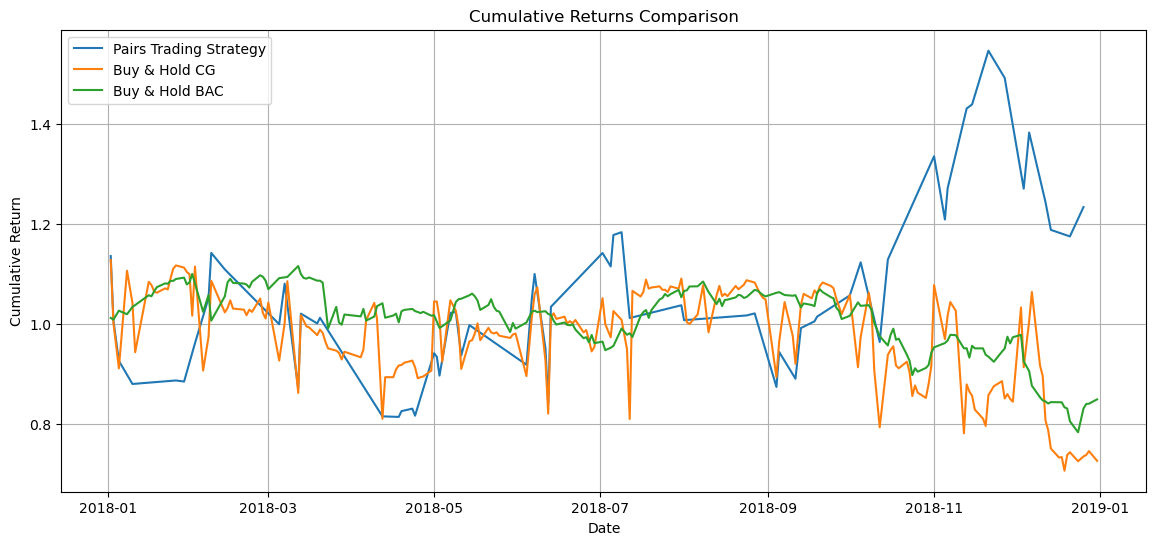

In [63]:
# Calculate cumulative returns
cumulative_pairs = np.cumprod(1 + df_return.dropna().groupby('Date')['changepct'].sum())
cumulative_cg = np.cumprod(1 + returns_trade[s1])
cumulative_bac = np.cumprod(1 + returns_trade[s2])

# Plot
plt.figure(figsize=(14, 6))
plt.plot(cumulative_pairs, label='Pairs Trading Strategy')
plt.plot(cumulative_cg, label=f'Buy & Hold {s1}')
plt.plot(cumulative_bac, label=f'Buy & Hold {s2}')

plt.title('Cumulative Returns Comparison')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

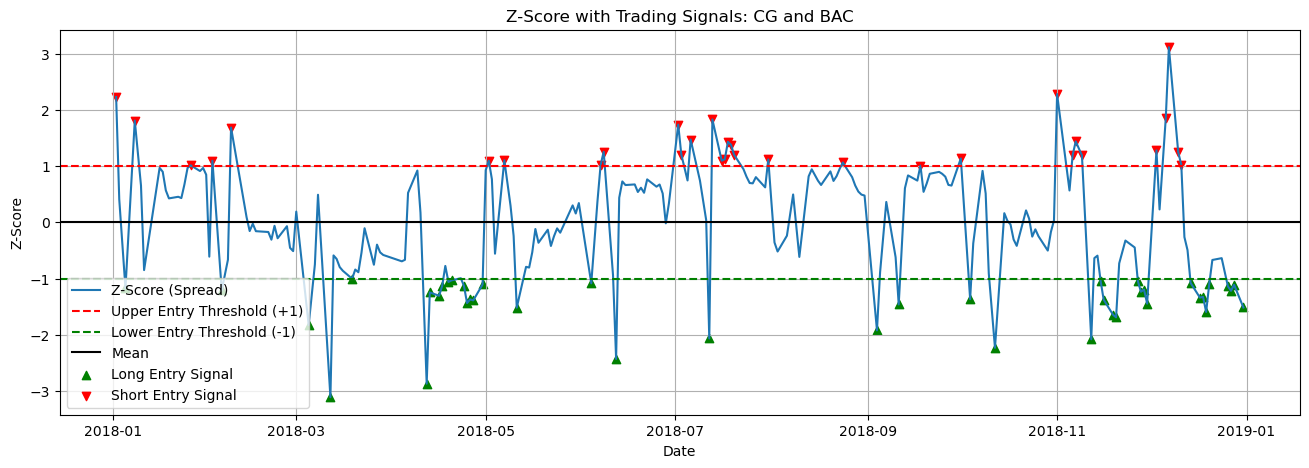

In [ ]:
plt.figure(figsize=(16, 5))
plt.plot(zscore_trade, label='Z-Score (Spread)')
plt.axhline(1, color='red', linestyle='--', label='Upper Entry Threshold (+1)')
plt.axhline(-1, color='green', linestyle='--', label='Lower Entry Threshold (-1)')
plt.axhline(0, color='black', linestyle='-', label='Mean')

# Signal markers
buy_signals = zscore_trade[positions == 1]
sell_signals = zscore_trade[positions == -1]
plt.scatter(buy_signals.index, buy_signals, marker='^', color='green', label='Long Entry Signal')
plt.scatter(sell_signals.index, sell_signals, marker='v', color='red', label='Short Entry Signal')

plt.title(f'Z-Score with Trading Signals: {s1} and {s2}')
plt.xlabel('Date')
plt.ylabel('Z-Score')
plt.legend()
plt.grid(True)
plt.show()

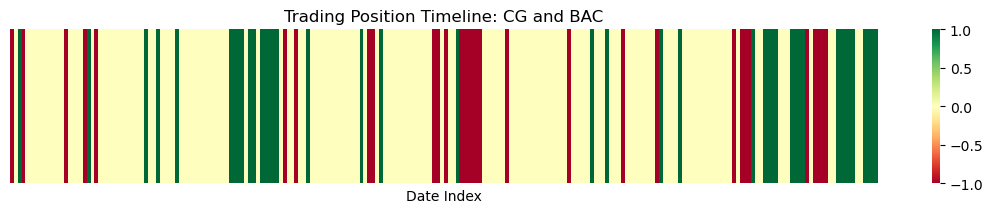

In [66]:
position_map = positions.replace({1: 'Long', -1: 'Short', 0: 'Neutral'})

plt.figure(figsize=(14, 2))
sns.heatmap(position_map.replace({'Long': 1, 'Short': -1, 'Neutral': 0}).values[np.newaxis, :], 
            cmap='RdYlGn', cbar=True, xticklabels=False)
plt.title(f'Trading Position Timeline: {s1} and {s2}')
plt.yticks([])
plt.xlabel('Date Index')
plt.show()

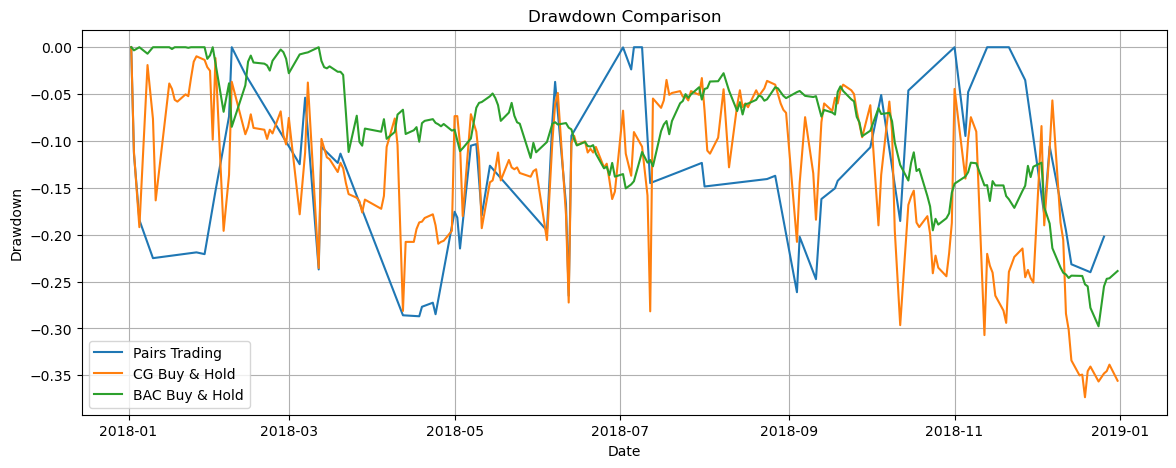

In [68]:
def calculate_drawdown(cum_returns):
    running_max = np.maximum.accumulate(cum_returns)
    drawdown = cum_returns / running_max - 1
    return drawdown

drawdown_pairs = calculate_drawdown(cumulative_pairs)
drawdown_cg = calculate_drawdown(cumulative_cg)
drawdown_bac = calculate_drawdown(cumulative_bac)

plt.figure(figsize=(14, 5))
plt.plot(drawdown_pairs, label='Pairs Trading')
plt.plot(drawdown_cg, label=f'{s1} Buy & Hold')
plt.plot(drawdown_bac, label=f'{s2} Buy & Hold')

plt.title('Drawdown Comparison')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.legend()
plt.grid(True)
plt.show()

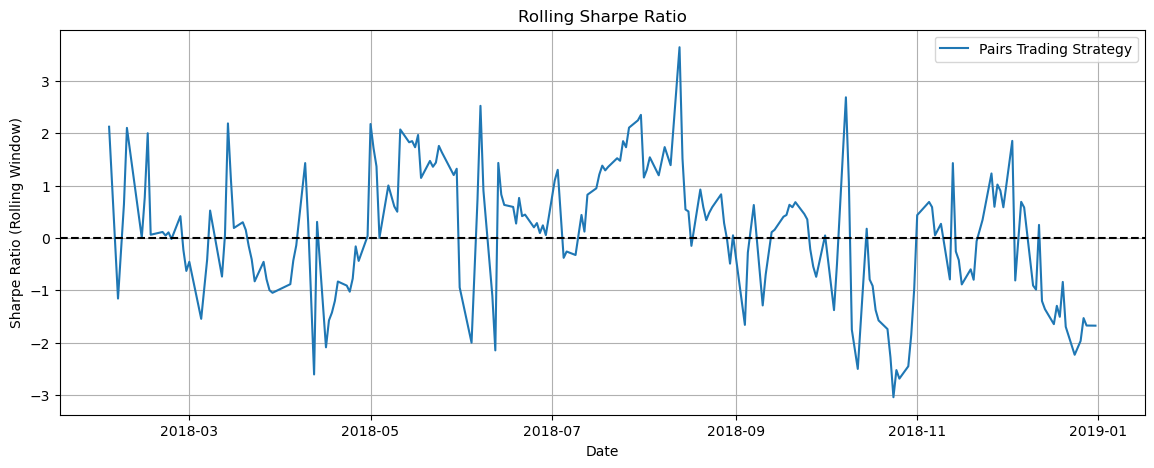

In [71]:
def rolling_sharpe(series, window=20):
    return (series.rolling(window).mean() / series.rolling(window).std()) * np.sqrt(252)

sharpe_pairs = rolling_sharpe(df_return.groupby('Date')['changepct'].sum())

plt.figure(figsize=(14, 5))
plt.plot(sharpe_pairs, label='Pairs Trading Strategy')
plt.axhline(0, color='black', linestyle='--')
plt.title('Rolling Sharpe Ratio')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio (Rolling Window)')
plt.legend()
plt.grid(True)
plt.show()